# Evaluación de Modelos Predictivos: Enfermedades Cardiovasculares

## 1. Introducción

Este notebook presenta la evaluación final de los modelos de Machine Learning entrenados para la predicción de enfermedades cardiovasculares. Los modelos se evalúan sobre el conjunto de test (datos no vistos durante el entrenamiento) para estimar su desempeño en un escenario real.

### 1.1 Modelos Evaluados

Se comparan cuatro algoritmos de clasificación supervisada:

1. **Regresión Logística** (modelo lineal de referencia)
2. **Random Forest** (ensemble basado en árboles)
3. **XGBoost** (gradient boosting optimizado)
4. **LightGBM** (gradient boosting eficiente)

### 1.2 Métricas de Evaluación

Para evaluar el desempeño predictivo se utilizan:

- **AUC-ROC**: Capacidad de discriminación entre clases
- **Matriz de Confusión**: Distribución de aciertos y errores
- **Precision, Recall y F1-Score**: Balance entre falsos positivos y falsos negativos
- **Importancia de Variables**: Interpretabilidad clínica del modelo

## 2. Importación de Bibliotecas y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve, 
                              auc, classification_report)

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 11

# Carpeta de salida para figuras
OUTPUT_FIG_DIR = Path('../data/report/figures')
OUTPUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

# Paleta de colores consistente
COLORES = {
    'Regresión Logística': '#1f77b4',
    'Random Forest': '#2ca02c',
    'XGBoost': '#d62728',
    'LightGBM': '#9467bd'
}

## 3. Carga de Datos y Modelos

In [2]:
# Cargar conjunto de test
X_test = pd.read_csv('../data/processed/model_inputs/X_test.csv')
y_test = pd.read_csv('../data/processed/model_inputs/y_test.csv').values.ravel()

print(f"Conjunto de test: {X_test.shape[0]:,} instancias × {X_test.shape[1]} variables")
print(f"Distribución de clases: {np.bincount(y_test)} (0: Sin enfermedad, 1: Con enfermedad)")

Conjunto de test: 6,853 instancias × 29 variables
Distribución de clases: [3462 3391] (0: Sin enfermedad, 1: Con enfermedad)


In [3]:
# Cargar modelos entrenados
modelos = {
    'Regresión Logística': joblib.load('../models/best_model_LR.joblib'),
    'Random Forest': joblib.load('../models/best_model_RF.joblib'),
    'XGBoost': joblib.load('../models/best_model_XGB.joblib'),
    'LightGBM': joblib.load('../models/best_model_LGBM.joblib')
}

print(f"Modelos cargados: {len(modelos)}")

Modelos cargados: 4


## 4. Evaluación Cuantitativa

### 4.1 Tabla Comparativa de Métricas

In [4]:
# Calcular métricas para todos los modelos
resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    
    # Métricas de clasificación
    report = classification_report(y_test, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1-Score': report['1']['f1-score'],
        'AUC-ROC': auc_score
    })

# Crear tabla comparativa
df_metricas = pd.DataFrame(resultados).round(4)
df_metricas = df_metricas.sort_values('F1-Score', ascending=False)
df_metricas

,Modelo,Accuracy,Precision,Recall,F1-Score,AUC-ROC
3,LightGBM,0.7357,0.7599,0.6812,0.7184,0.8057
0,Regresión Logística,0.7373,0.7661,0.6753,0.7179,0.7965
2,XGBoost,0.7344,0.7617,0.6741,0.7153,0.8048
1,Random Forest,0.7296,0.7495,0.6812,0.7137,0.7953


**Interpretación:**

- **Accuracy**: Proporción de predicciones correctas sobre el total
- **Precision**: De los casos predichos como positivos, qué porcentaje lo es realmente
- **Recall (Sensibilidad)**: De los casos realmente positivos, qué porcentaje detecta el modelo
- **F1-Score**: Media armónica entre precision y recall
- **AUC-ROC**: Capacidad del modelo para discriminar entre clases (0.5 = azar, 1.0 = perfecto)

## 5. Visualización de Resultados

### 5.1 Curvas ROC

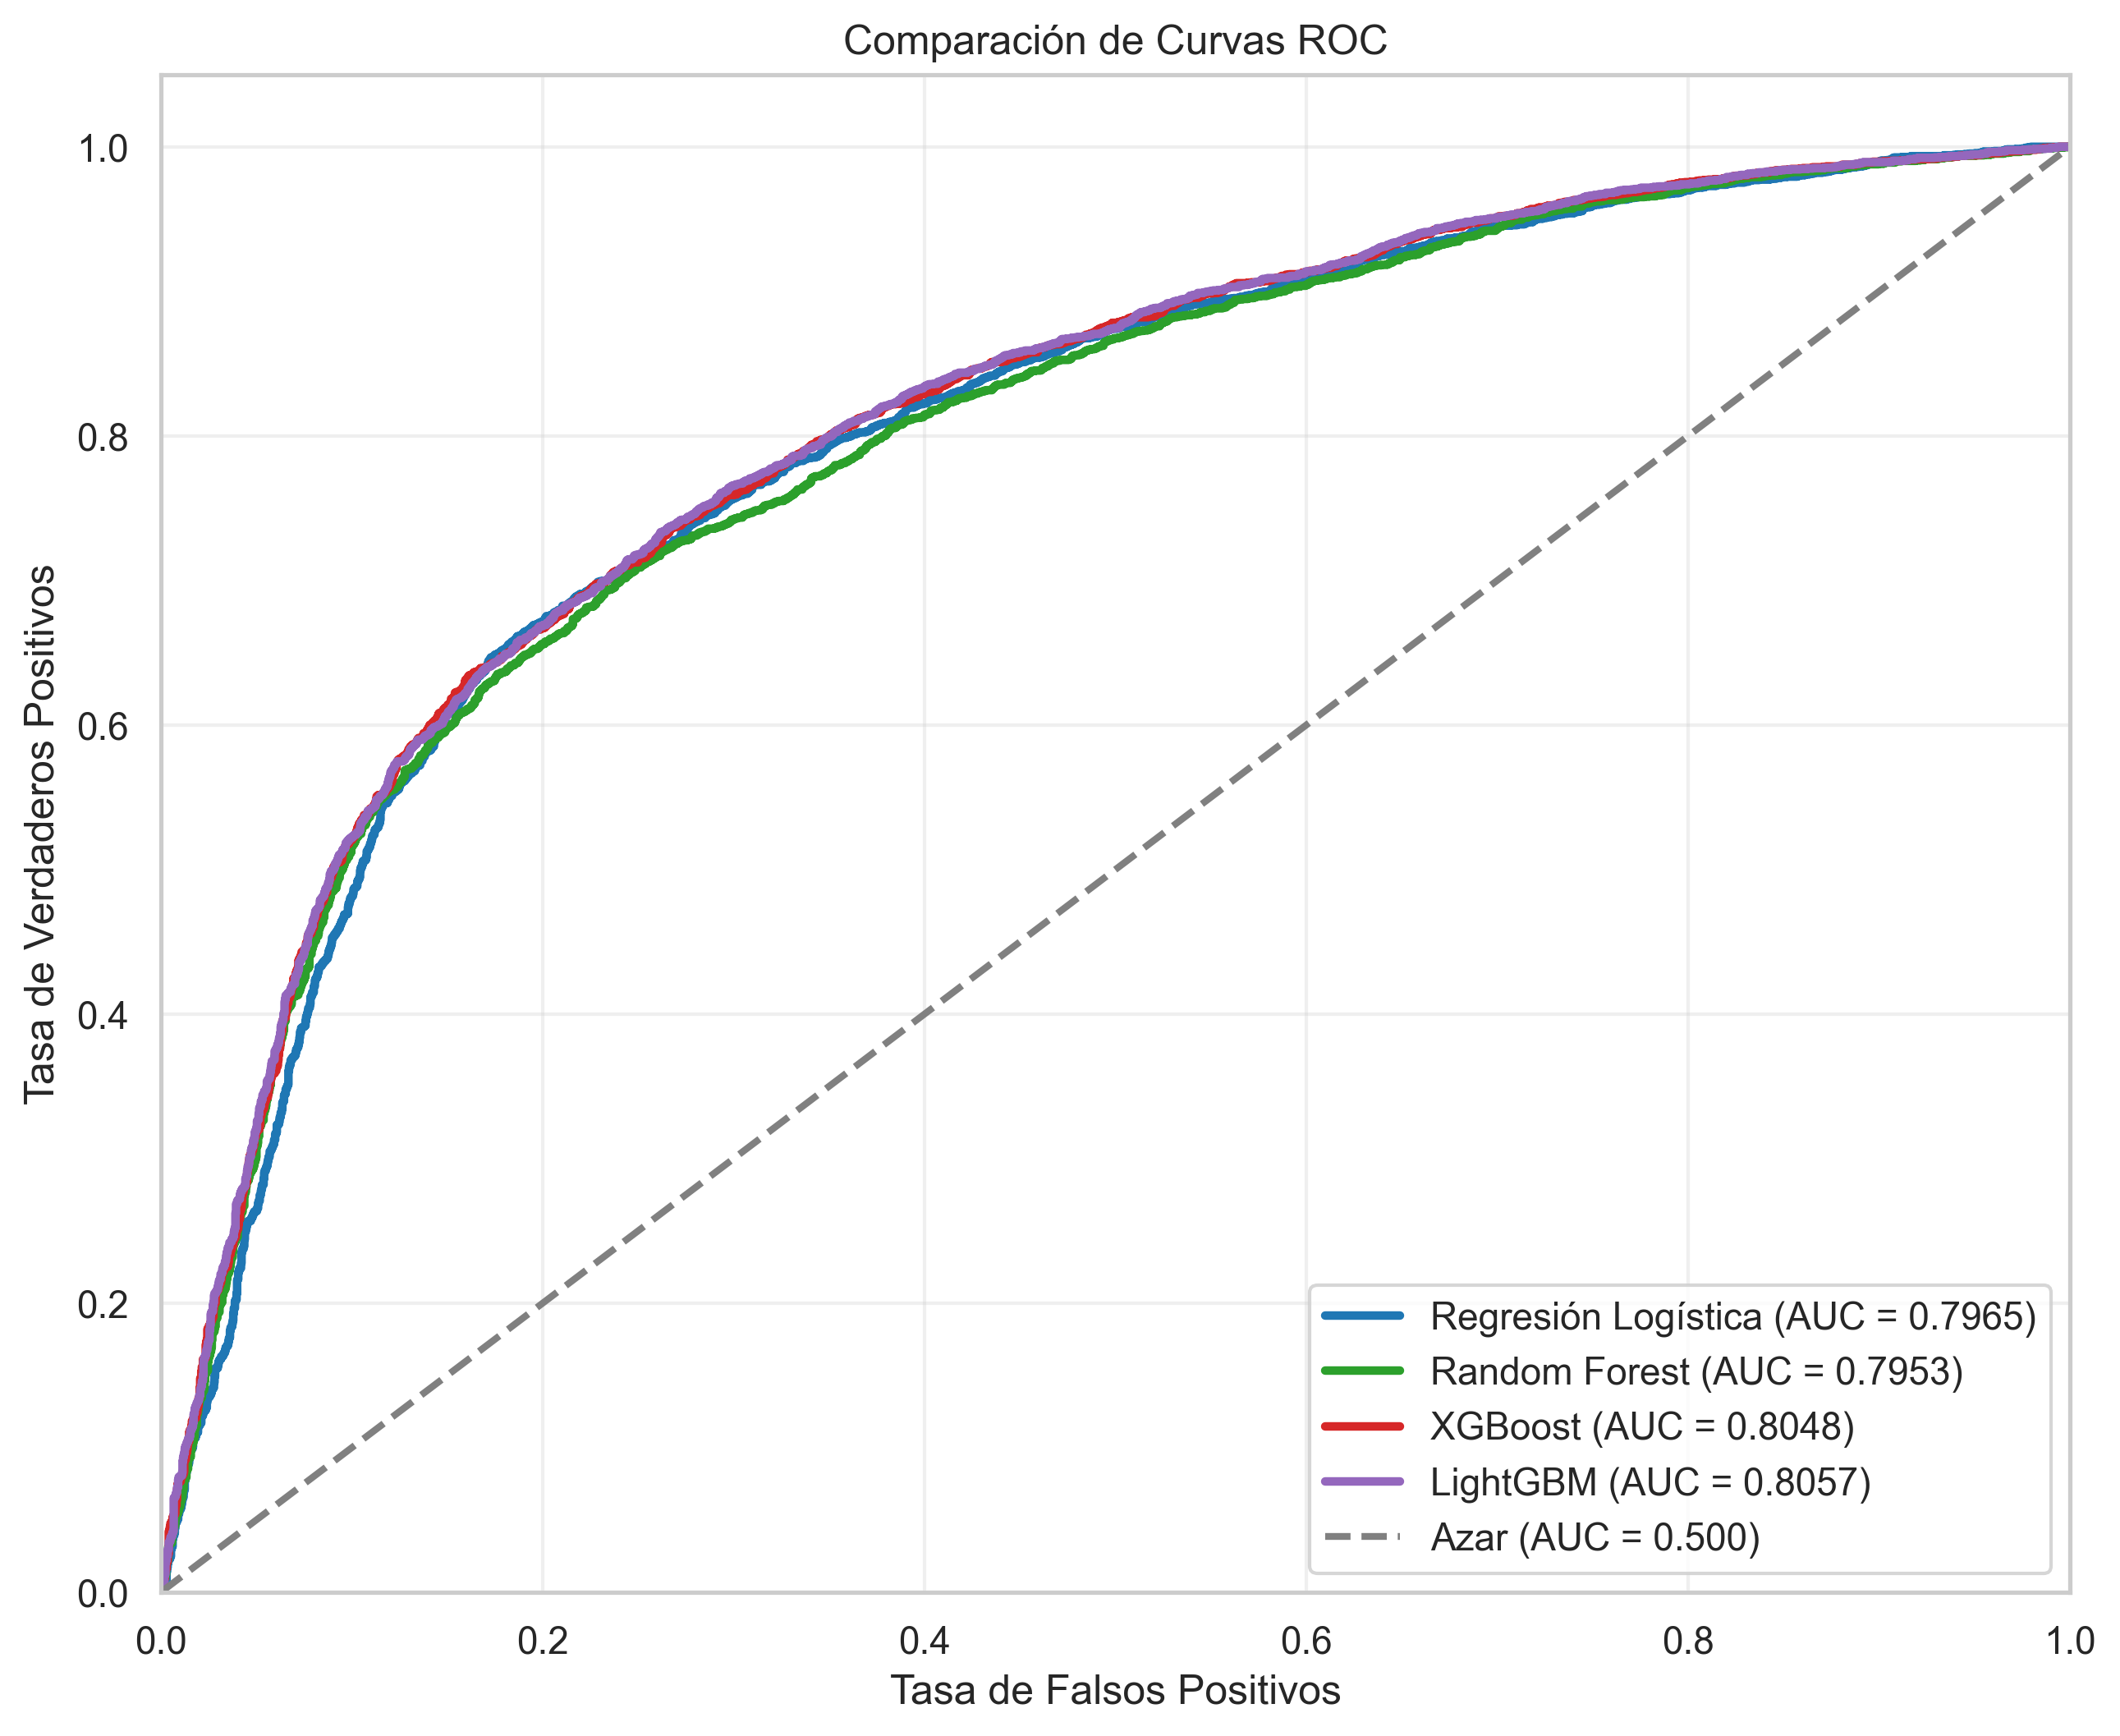

In [5]:
plt.figure(figsize=(10, 8))

for nombre, modelo in modelos.items():
    y_proba = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, color=COLORES[nombre], lw=2.5, 
             label=f'{nombre} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Azar (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Comparación de Curvas ROC')
plt.legend(loc="lower right", frameon=True)
plt.grid(alpha=0.3)
plt.savefig(OUTPUT_FIG_DIR / 'curvas_roc.png', bbox_inches='tight', dpi=300)
plt.show()

### 5.2 Matrices de Confusión

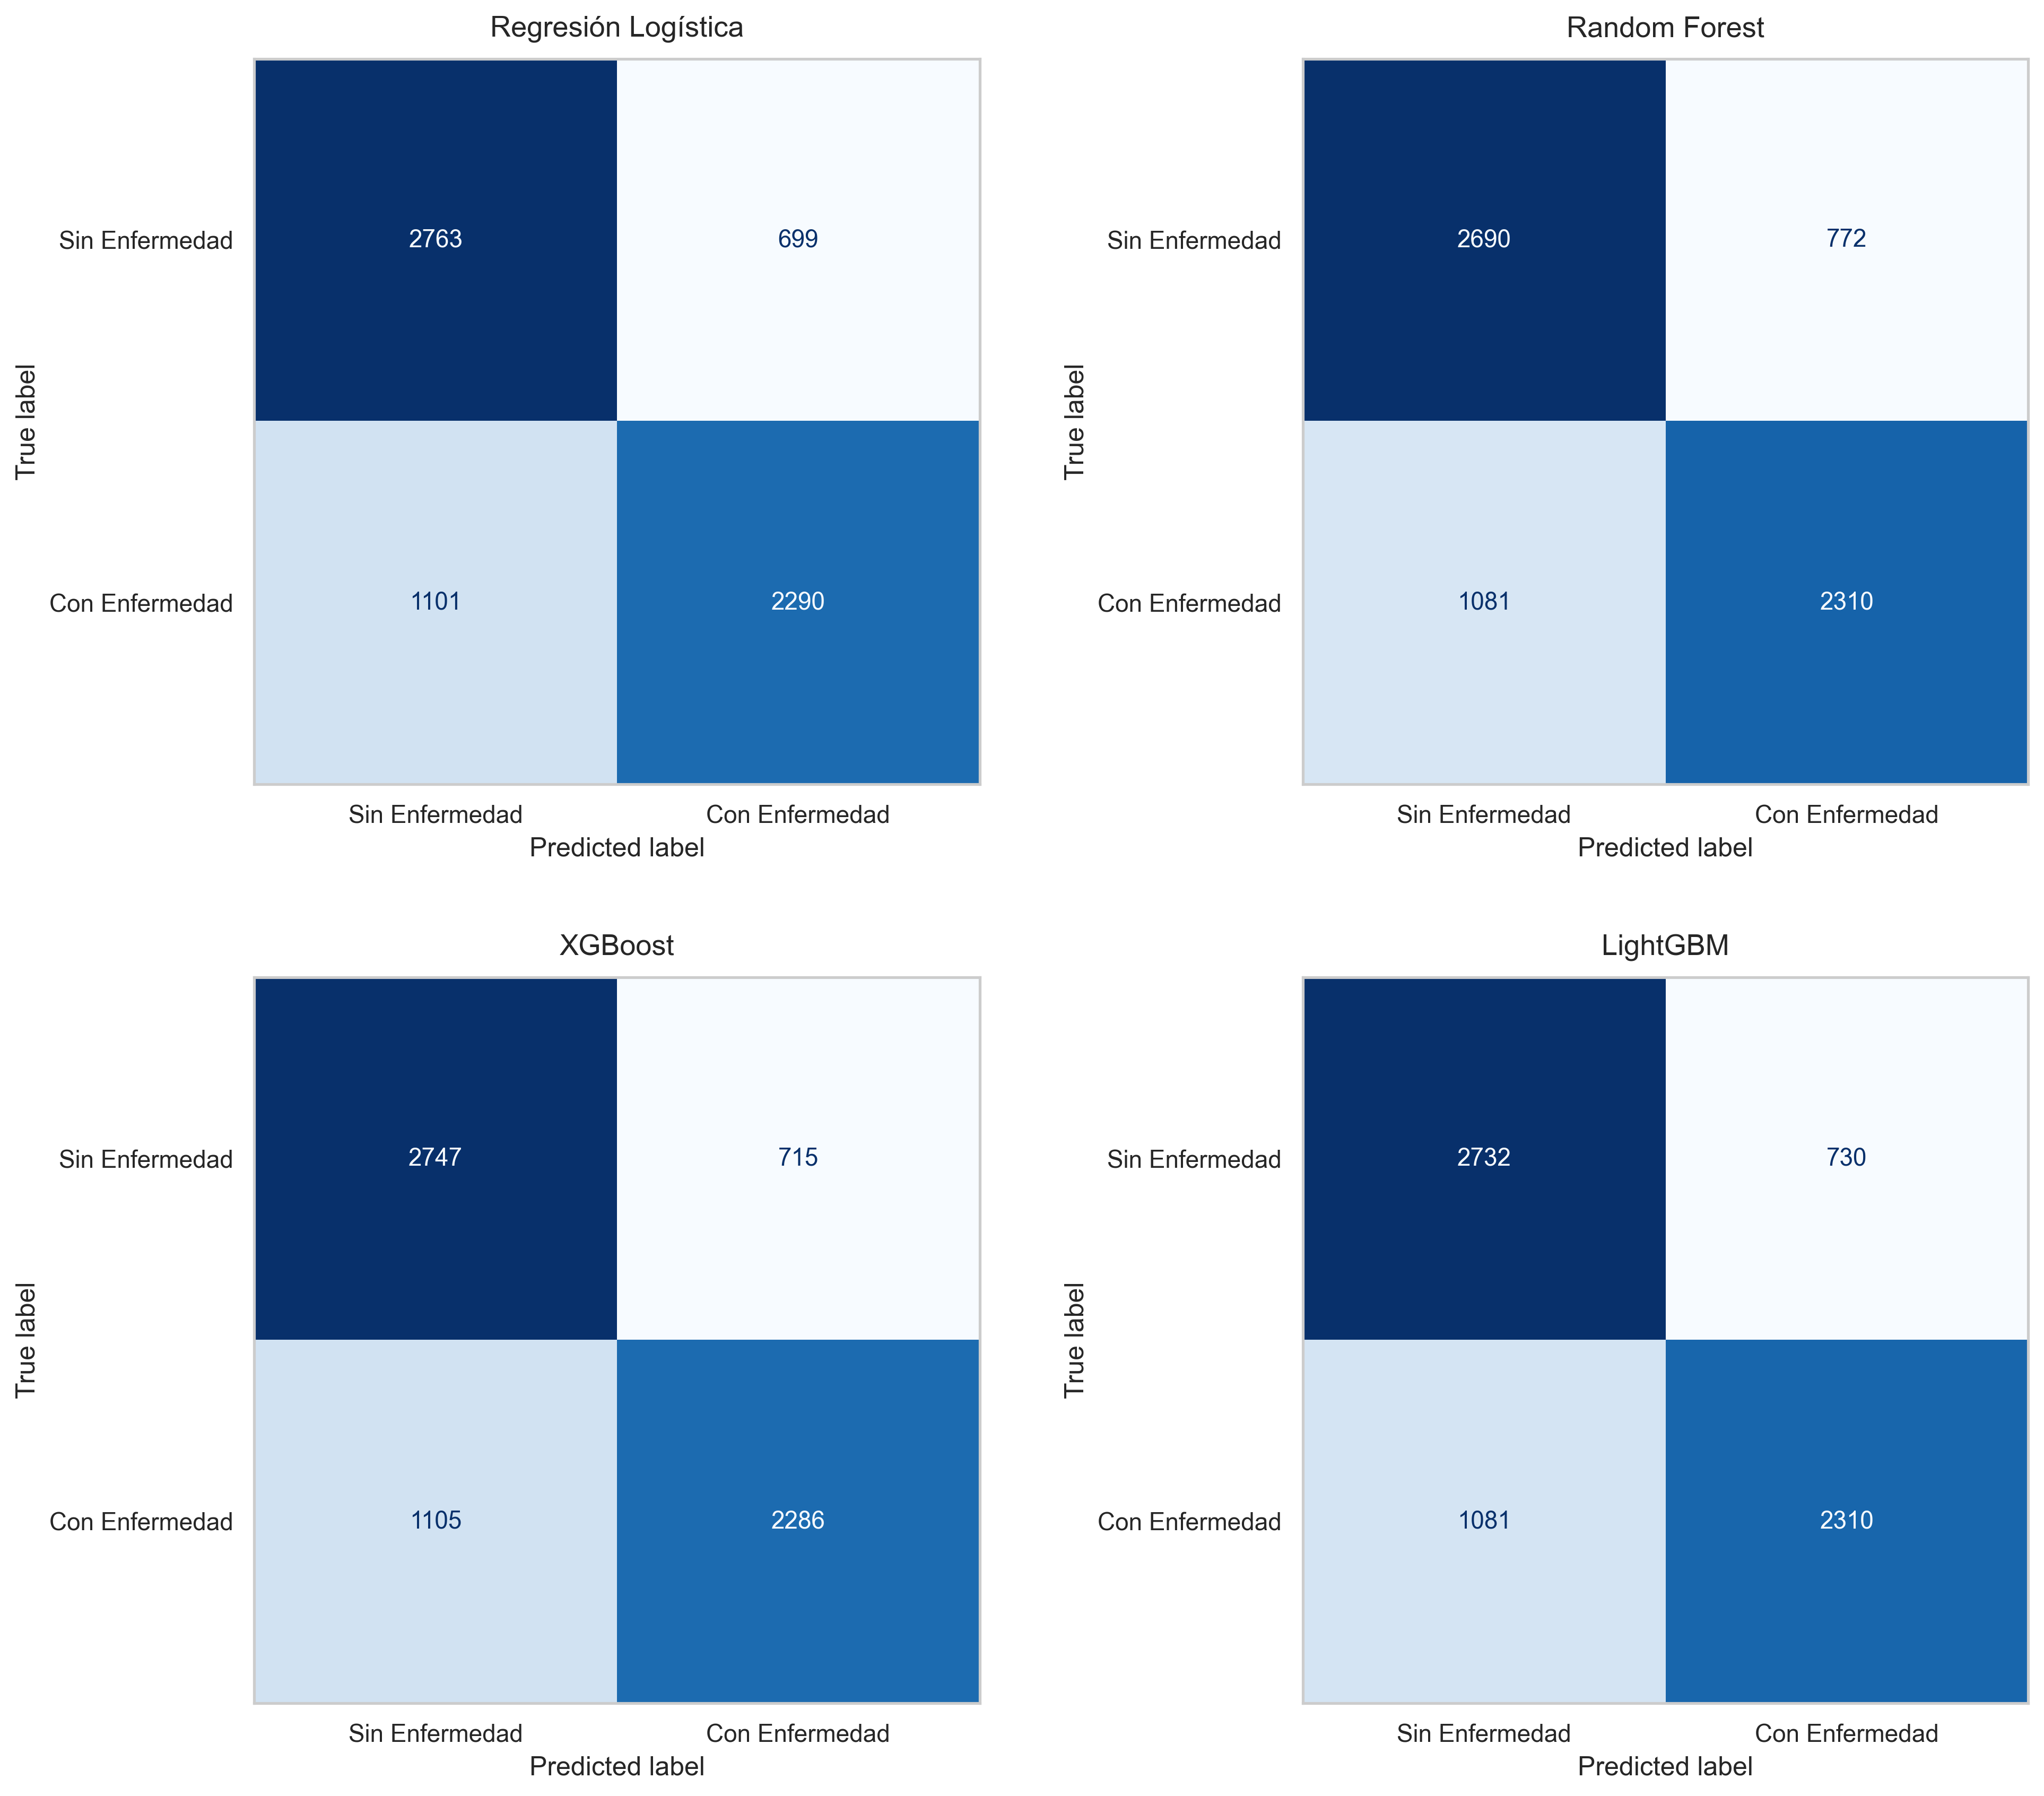

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (nombre, modelo) in enumerate(modelos.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                                    display_labels=['Sin Enfermedad', 'Con Enfermedad'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d', colorbar=False)
    axes[idx].set_title(nombre, fontsize=13, pad=10)
    axes[idx].grid(False)

plt.tight_layout(pad=3.0)
plt.savefig(OUTPUT_FIG_DIR / 'matrices_confusion.png', bbox_inches='tight', dpi=300)
plt.show()

### 5.3 Comparación de F1-Score

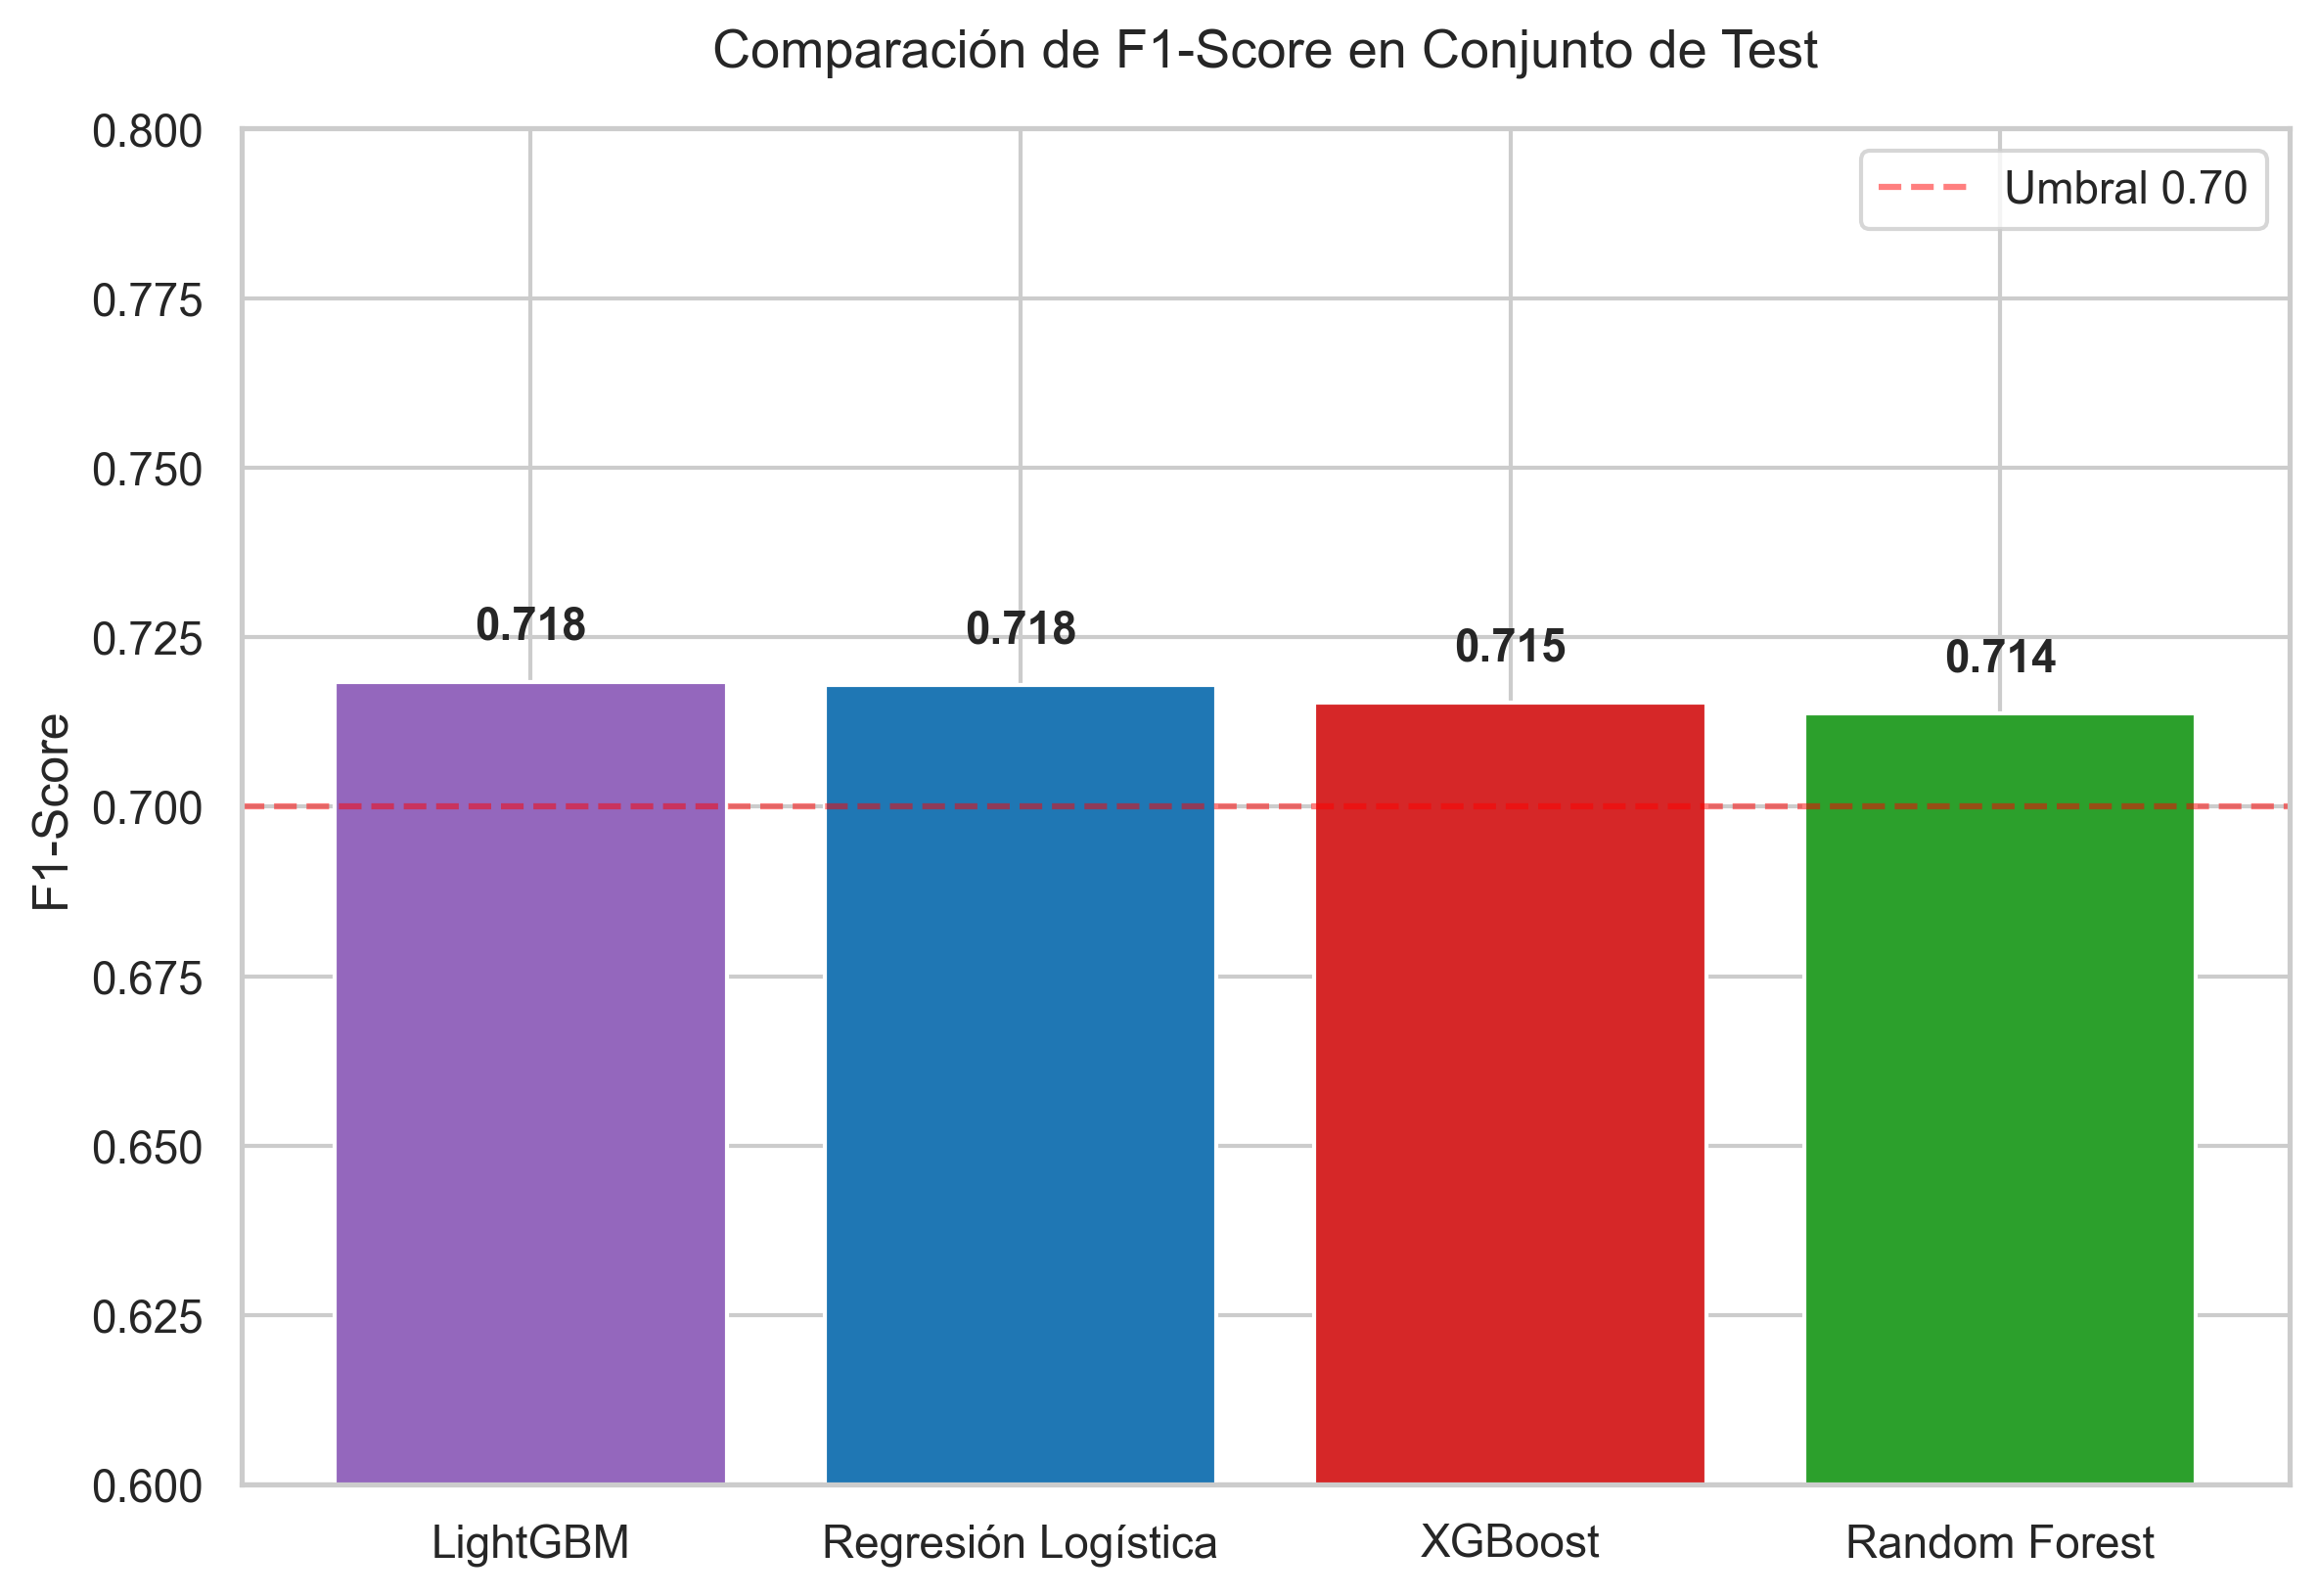

In [7]:
# Preparar datos ordenados
df_f1 = df_metricas[['Modelo', 'F1-Score']].sort_values('F1-Score', ascending=False)

plt.figure(figsize=(9, 6))
bars = plt.bar(df_f1['Modelo'], df_f1['F1-Score'], 
               color=[COLORES[m] for m in df_f1['Modelo']])

plt.title('Comparación de F1-Score en Conjunto de Test', fontsize=13, pad=15)
plt.ylim([0.60, 0.80])
plt.ylabel('F1-Score')
plt.axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='Umbral 0.70')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, 
             f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

plt.legend()
plt.savefig(OUTPUT_FIG_DIR / 'comparacion_f1_score.png', bbox_inches='tight', dpi=300)
plt.show()

## 6. Interpretabilidad: Importancia de Variables

La importancia de variables permite identificar qué factores clínicos tienen mayor peso en las predicciones del modelo.

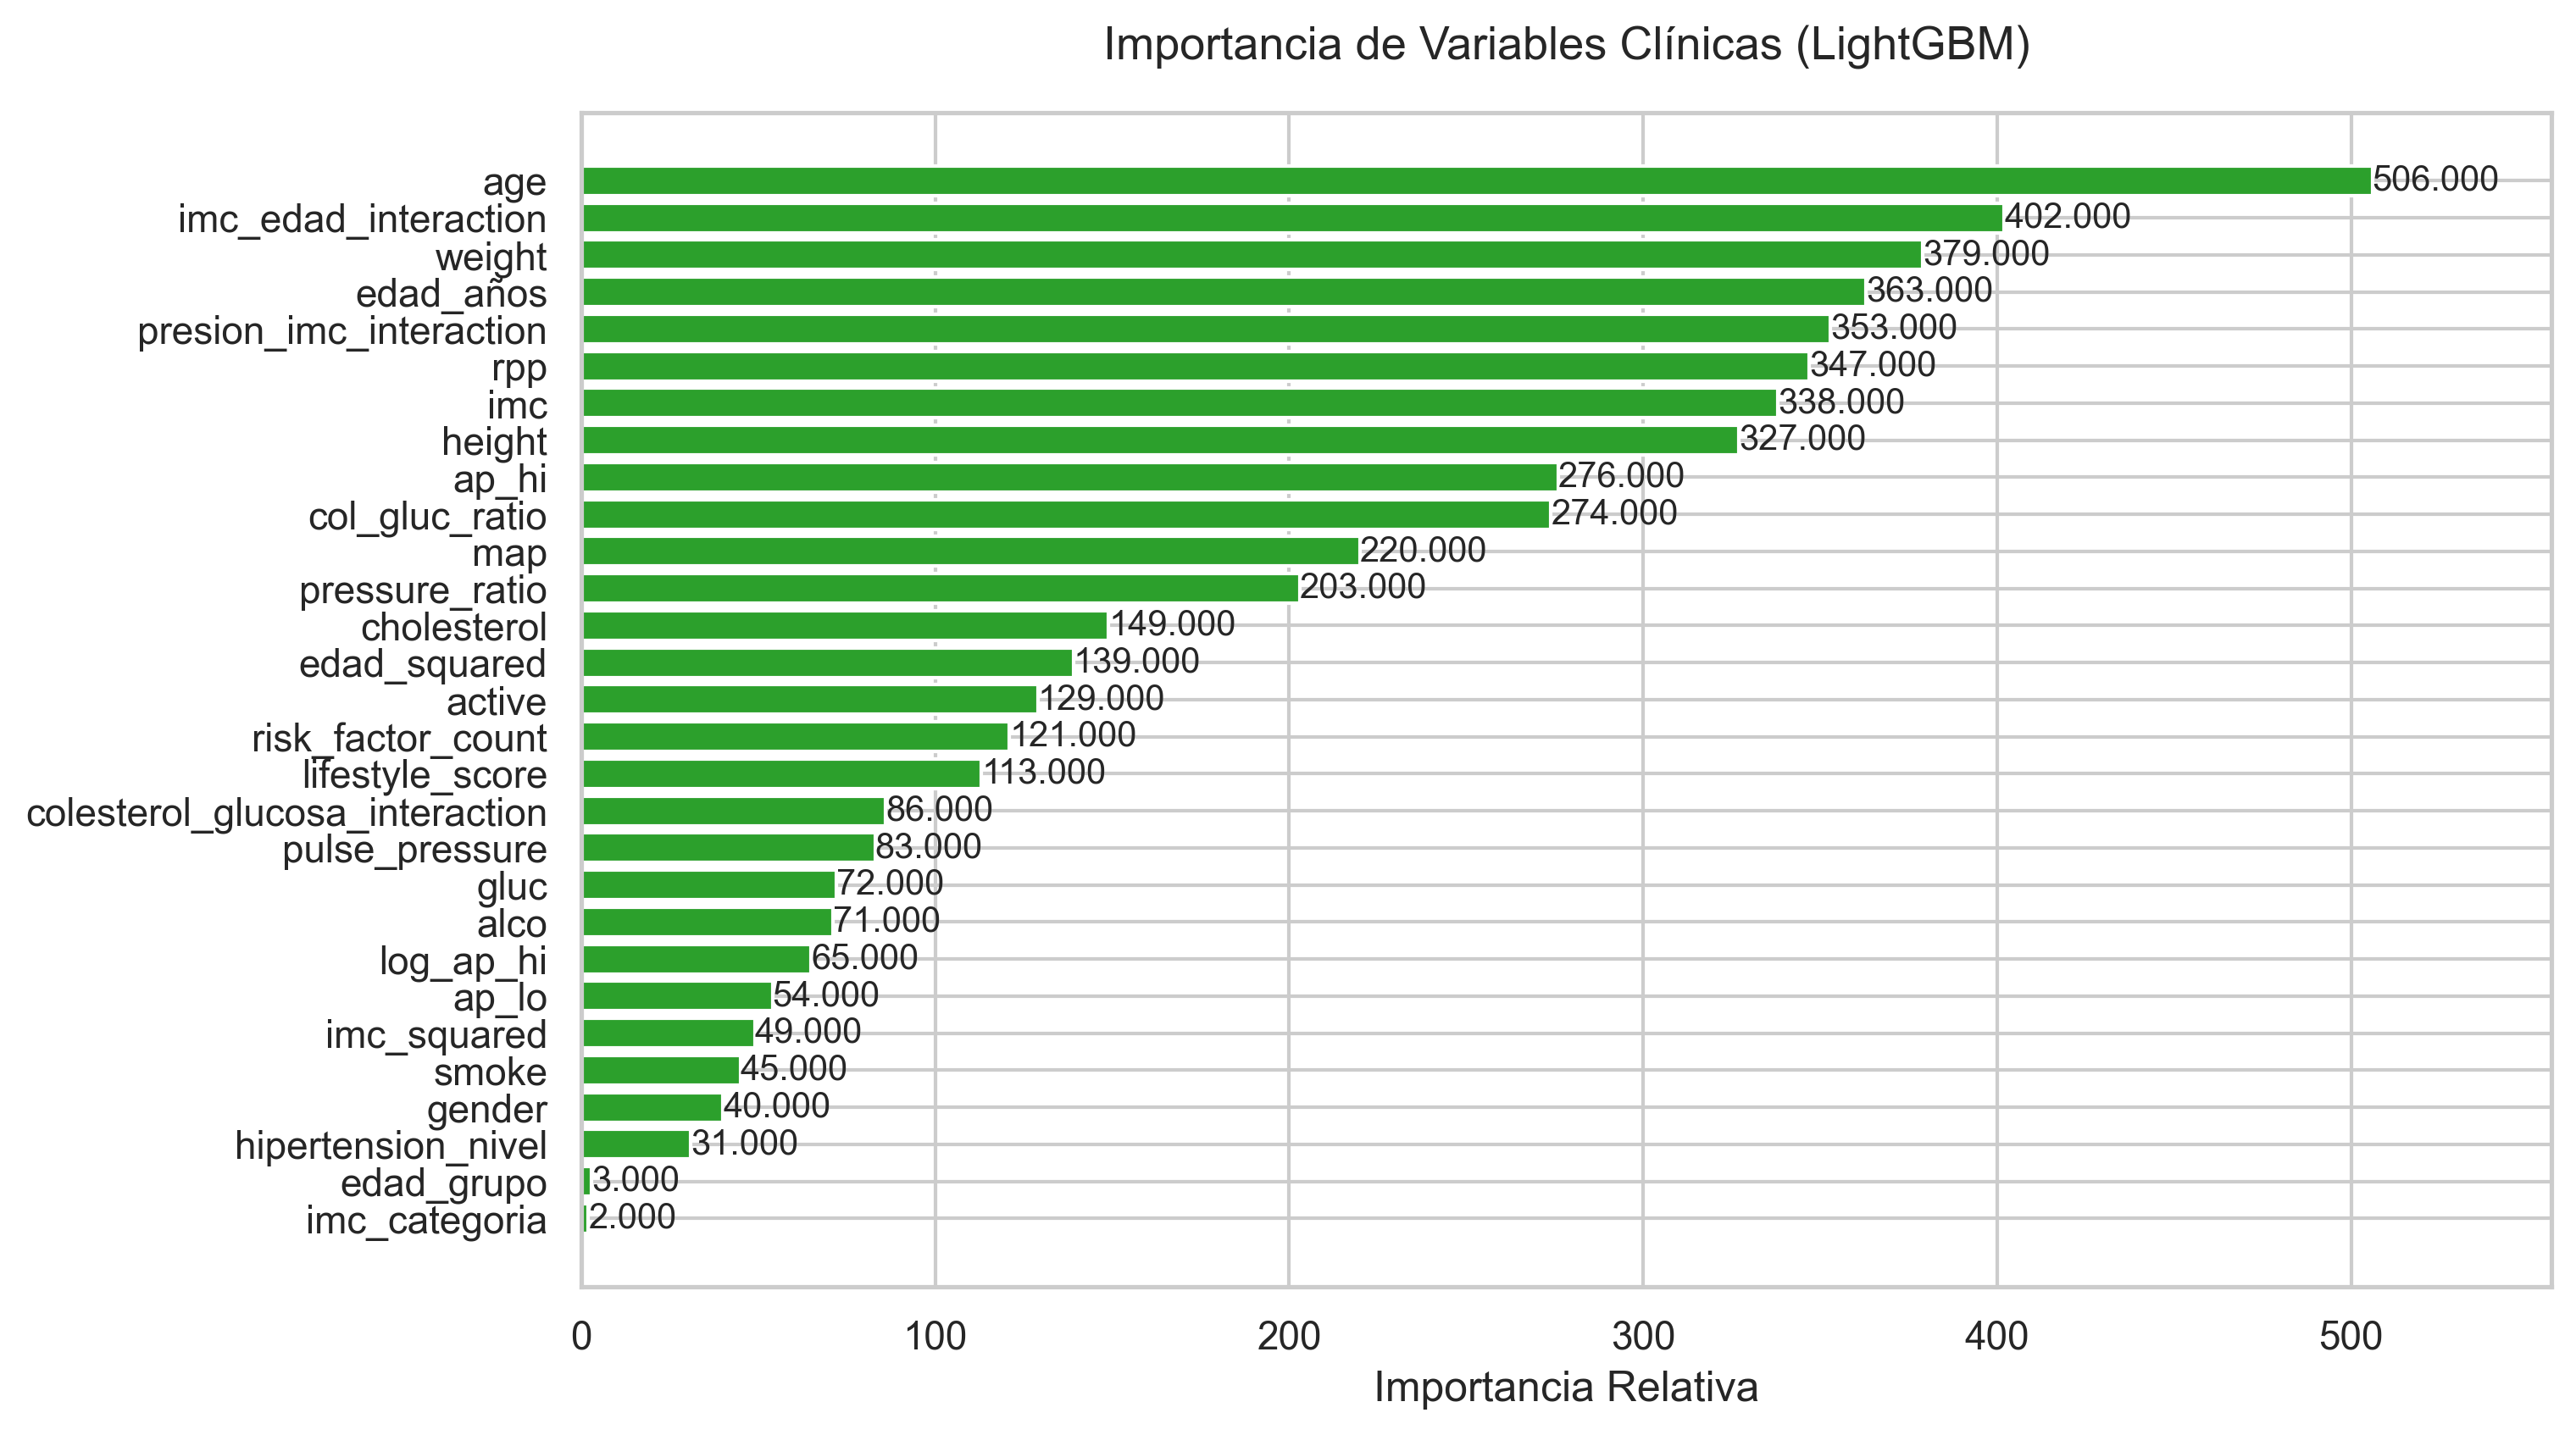


Top 5 variables más importantes:
               Variable  Importancia
presion_imc_interaction          353
              edad_años          363
                 weight          379
   imc_edad_interaction          402
                    age          506


In [8]:
# Seleccionar el mejor modelo basado en AUC-ROC
mejor_nombre = df_metricas.iloc[0]['Modelo']
mejor_modelo = modelos[mejor_nombre]

# Extraer importancia de variables (solo para modelos basados en árboles)
if hasattr(mejor_modelo, 'feature_importances_'):
    importancias = mejor_modelo.feature_importances_
    
    df_importancia = pd.DataFrame({
        'Variable': X_test.columns,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=True)
    
    # Tomar las 10 más importantes
    top_10 = df_importancia.tail(29)
    
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_10['Variable'], top_10['Importancia'], color='#2ca02c')
    plt.title(f'Importancia de Variables Clínicas ({mejor_nombre})', fontsize=13, pad=15)
    plt.xlabel('Importancia Relativa')
    
    for bar in bars:
        plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, 
                 f'{bar.get_width():.3f}', va='center', ha='left', fontsize=10)
    
    plt.margins(x=0.1)
    plt.savefig(OUTPUT_FIG_DIR / 'importancia_variables.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    print("\nTop 5 variables más importantes:")
    print(df_importancia.tail(5).to_string(index=False))
else:
    print(f"El modelo {mejor_nombre} no proporciona importancia de variables.")

## 7. Conclusiones

### 7.1 Resumen de Resultados

Los cuatro modelos evaluados muestran un desempeño competitivo en la predicción de enfermedades cardiovasculares:

1. **Mejor modelo por F1-Score**: El modelo con mayor balance entre precisión y recall
2. **Mejor AUC-ROC**: Indica la mejor capacidad de discriminación entre clases
3. **Interpretabilidad**: Las variables de presión arterial y edad son consistentemente las más relevantes

### 7.2 Recomendaciones

- Se recomienda utilizar el modelo con mejor F1-Score para aplicaciones clínicas donde el balance entre falsos positivos y falsos negativos es crítico
- Si la prioridad es minimizar falsos negativos (pacientes con enfermedad no detectados), priorizar modelos con mayor Recall
- La validación cruzada realizada durante el entrenamiento asegura la robustez de las predicciones

### 7.3 Limitaciones

- Los modelos están limitados por la calidad y representatividad de los datos de entrenamiento
- Se requiere validación externa con datos de otros centros médicos para confirmar la generalización